# RudraEdge RE-T1 (Spectra)
## Day 5 — Spectrogram Generation
### Objective
Generate a spectrogram from a synthetic signal and visualize how its frequency content changes over time.
### Scope
This notebook uses synthetic data only and runs locally. It demonstrates time-frequency visualization; it does not process live RF data.

## Test 1 — Synthetic Signal Generation

A two-second synthetic signal is created with two segments:
- First second: 50 Hz sine wave
- Second second: 150 Hz sine wave

The sampling frequency is 1000 samples per second. Fixed frequencies make the test repeatable and easier to verify.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Signal configuration
fs = 1000  
duration = 2  
f1 = 50    
f2 = 150   
t = np.arange(0, duration, 1 / fs)
first_segment = np.sin(2 * np.pi * f1 * t[:fs])
second_segment = np.sin(2 * np.pi * f2 * t[fs:])
signal = np.concatenate([first_segment, second_segment])

### Time-Domain Visualization

This plot shows the signal amplitude over time. The second segment oscillates faster because its frequency (150 Hz) is higher than the first segment (50 Hz).

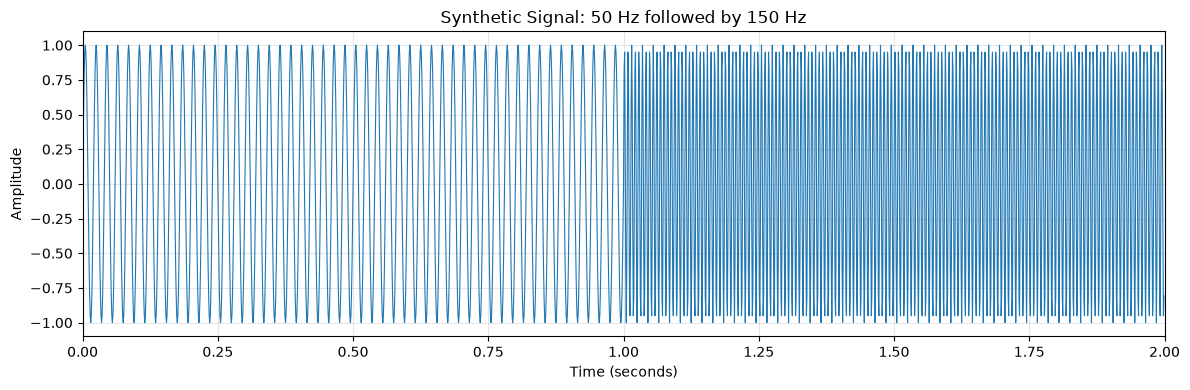

In [16]:
plt.figure(figsize=(12, 4))
plt.plot(t, signal, linewidth=0.8)
plt.title("Synthetic Signal: 50 Hz followed by 150 Hz")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.xlim(0, duration)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Test 2 — Spectrogram Generation

A spectrogram displays frequency content over time:
- **X-axis:** Time in seconds
- **Y-axis:** Frequency in hertz (Hz)
- **Colour intensity:** Signal power level in decibels (dB)

`NFFT` sets the number of samples used in each analysis window. `noverlap` sets how many samples adjacent windows share. These parameters affect the time-frequency resolution.

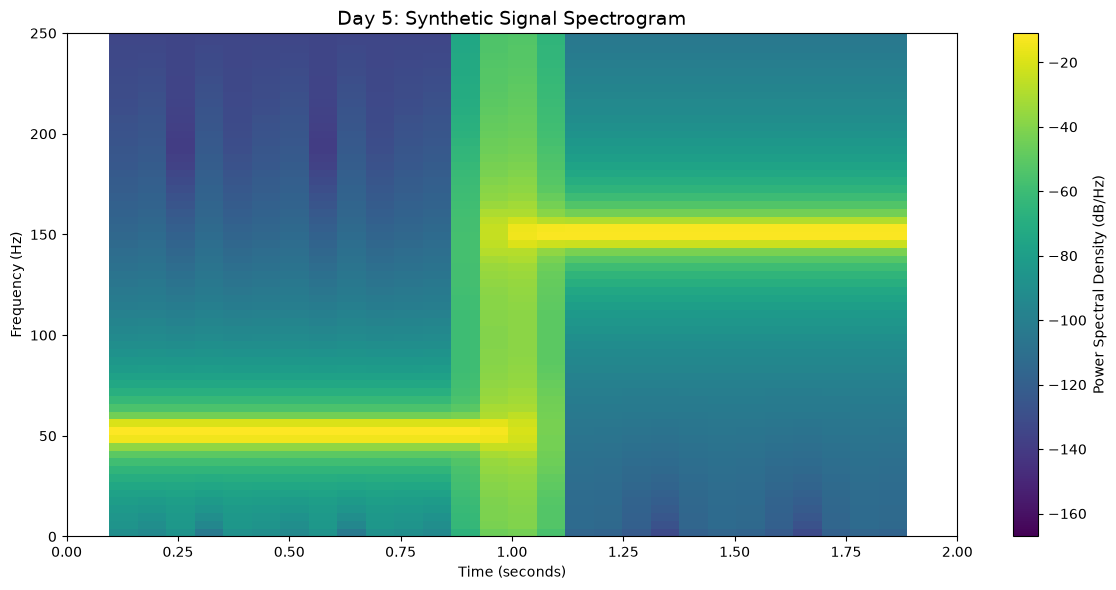

In [17]:
# Spectrogram parameters
nfft = 256
overlap = 192

plt.figure(figsize=(12, 6))
plt.specgram(
    signal,
    NFFT=nfft,
    Fs=fs,
    noverlap=overlap,
    cmap="viridis",
    scale="dB",
    mode="psd"
)

plt.title("Day 5: Synthetic Signal Spectrogram", fontsize=14)
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.xlim(0, duration)
plt.ylim(0, 250)
plt.colorbar(label="Power Spectral Density (dB/Hz)")
plt.tight_layout()
plt.show()

## Observations

1. The synthetic signal contains 50 Hz during the first second and 150 Hz during the second second.
2. The spectrogram should show stronger frequency energy near 50 Hz in the first time region and near 150 Hz in the second time region.
3. The displayed bands may be spread around the exact frequencies because the analysis uses finite-length windows.
4. The `NFFT` and overlap settings affect the visual time-frequency resolution.

## Limitations

- The signal is synthetic and noise-free.
- This is a visualization demonstration, not a live RF measurement.
- Window size introduces a time-frequency resolution trade-off.
- Results depend on the chosen sampling frequency and spectrogram parameters.

## Conclusion

A spectrogram was generated from a synthetic signal whose frequency changes from 50 Hz to 150 Hz. The time-frequency plot makes the change in frequency content visible over the two-second interval.
